In [1]:
%pip install pandas pyarrow ydata-profiling scikit-learn ipywidgets seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.cluster import KMeans

import methods

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
train_df = pd.read_parquet("train.parquet", engine="pyarrow")
test_df = pd.read_parquet("test.parquet", engine="pyarrow")
train_df["__is_train"] = 1
test_df["__is_train"] = 0
test_df["qty"] = np.nan
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Разделяем на train и val
max_date = train_df["dt"].max()
val_start = max_date - pd.Timedelta(days=45)
val_end = test_df["dt"].min()
full_df["__is_val"] = (
    (full_df["dt"] >= val_start)
    & (full_df["dt"] < val_end)
    & (full_df["__is_train"] == 1)
).astype(int)

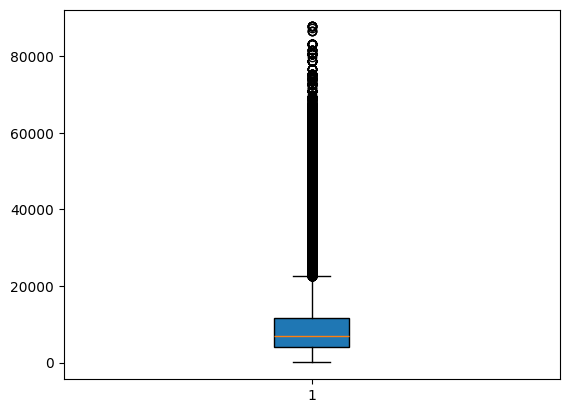

In [5]:
plt.boxplot(full_df["price"], vert=True, patch_artist=True)
plt.show()

In [6]:
full_df["log_price"] = np.log1p(full_df["price"])

In [7]:
full_df["price_cluster"] = KMeans(
    n_clusters=5, random_state=0, n_init="auto"
).fit_predict(full_df[["log_price"]])

In [8]:
full_df["price_cluster"] = full_df["price_cluster"].astype("category")
full_df["price_cluster"].describe()

count     322504
unique         5
top            3
freq       90288
Name: price_cluster, dtype: int64

In [10]:
full_df = full_df.sort_values(["dt"])

<Axes: >

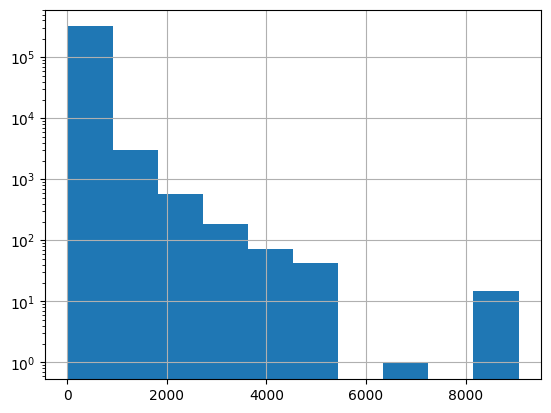

In [11]:
full_df["prev_leftovers"].hist(log=True)

In [12]:
full_df["log_prev_leftovers"] = np.log1p(full_df["prev_leftovers"])

<Axes: >

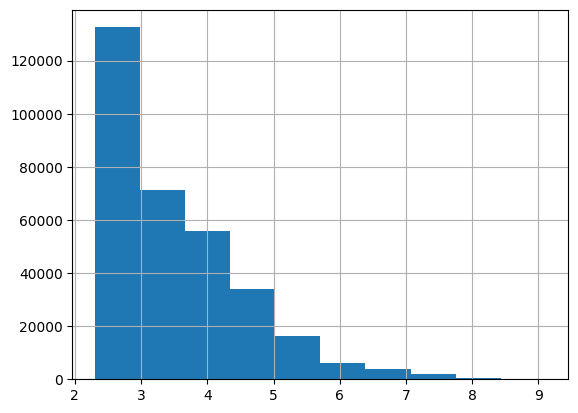

In [13]:
full_df["log_prev_leftovers"].hist()

In [14]:
# Добавляем признак is_rus_holiday
full_df = methods.add_russian_calendar_features(full_df)

# Добавляем признаки для дат
full_df = methods.add_date_features(full_df)

# Добавляем лаговые признаки по продуктам
full_df = methods.add_lag_features(full_df)

# Добавляем глобальные лаги продаж
full_df = methods.add_global_lags(full_df)

# Добавляем признаки динамики продаж
full_df = methods.add_product_activity_features(full_df)

# Добавляем складские признаки
full_df = methods.add_leftover_change_features(full_df)

# Добавляем признаки сезонности
full_df = methods.add_seasonality_flags(full_df)

In [15]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322504 entries, 0 to 322503
Data columns (total 53 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   nm_id                       322504 non-null  object        
 1   dt                          322504 non-null  datetime64[ns]
 2   qty                         309648 non-null  float64       
 3   price                       322504 non-null  int64         
 4   is_promo                    322504 non-null  int64         
 5   prev_leftovers              322504 non-null  int64         
 6   __is_train                  322504 non-null  int64         
 7   __is_val                    322504 non-null  int64         
 8   log_price                   322504 non-null  float64       
 9   price_cluster               322504 non-null  category      
 10  log_prev_leftovers          322504 non-null  float64       
 11  is_preholiday               322504 non-

In [16]:
full_df["dt_num"] = (full_df["dt"] - full_df["dt"].min()).dt.days
full_df["nm_id"] = full_df["nm_id"].astype("category")
full_df["day_of_week"] = full_df["day_of_week"].astype("category")
full_df["week_of_year"] = full_df["week_of_year"].astype("category")


In [18]:
feature_cols = [
    # Базовые признаки товара
    "nm_id",
    "log_price",  # или "log_price"
    "is_promo",
    "log_prev_leftovers",
    "price_cluster",
    # Временные признаки
    "day_of_week",
    "month",
    "week_of_year",
    "is_weeked",
    "is_non_working_day_rus",
    "is_preholiday",
    # Лаги продаж (самые важные)
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    # Скользящие средние
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    # Волатильность
    "rolling_std_3",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_30",
    # Минимумы/максимумы
    "rolling_max_7",
    "rolling_max_14",
    "rolling_min_7",
    "rolling_min_14",
    # EWMA
    "ewm_alpha_0.3",
    # Признак дня недели
    "same_day_last_week",
    # Складские признаки
    "days_since_leftover_change",
    "leftovers_changed",
    "leftovers_changed_lag",
    # Глобальные тренды
    "global_sales",
    "global_lag_1",
    "global_lag_7",
    "global_lag_14",
    # Признаки продаж
    "was_sale",
    "days_since_last_sale",
    "sales_last_30",
    "sale_days_last_30",
    # Признаки сезонности
    "high_season",
    "cold_season",
]

cat_cols = [
    "nm_id",
    "price_cluster",
    "day_of_week",
    "month",
    "week_of_year",
]

In [19]:
def wmae_metric(y_true, y_pred):
    """
    WMAE where:
        w = 1  if final prediction == 0
        w = 7  if final prediction > 0
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    weights = np.where(y_pred <= 0, 1.0, 7.0)
    errors = weights * np.abs(y_true - y_pred)

    return errors.sum() / weights.sum()

In [20]:
# ===============================
# 1. Разделение данных
# ===============================

train_df = full_df[(full_df["__is_val"] == 0) & (full_df["qty"].notna())].copy()
val_df   = full_df[(full_df["__is_val"] == 1) & (full_df["qty"].notna())].copy()

train_df["sale"] = (train_df["qty"] > 0).astype(int)
val_df["sale"]   = (val_df["qty"] > 0).astype(int)

# ===============================
# 2. Классификатор
# ===============================

clf = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=200,
    cat_features=cat_cols,
)

clf.fit(
    train_df[feature_cols],
    train_df["sale"],
    eval_set=(val_df[feature_cols], val_df["sale"]),
    use_best_model=True
)

# ===============================
# 3. Регрессор (только реальные положительные qty)
# ===============================

reg_train = train_df[train_df["qty"] > 0].copy()

reg = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="MAE",
    random_seed=42,
    verbose=200,
    cat_features=cat_cols,
)

reg.fit(
    reg_train[feature_cols],
    reg_train["qty"]
)


0:	test: 0.8685956	best: 0.8685956 (0)	total: 327ms	remaining: 4m 21s
200:	test: 0.8193045	best: 0.8909038 (27)	total: 38.6s	remaining: 1m 55s
400:	test: 0.7447798	best: 0.8909038 (27)	total: 1m 18s	remaining: 1m 18s
600:	test: 0.6605937	best: 0.8909038 (27)	total: 1m 57s	remaining: 38.8s
799:	test: 0.6085865	best: 0.8909038 (27)	total: 2m 36s	remaining: 0us

bestTest = 0.8909037816
bestIteration = 27

Shrink model to first 28 iterations.
0:	learn: 3.2342269	total: 65ms	remaining: 2m 9s
200:	learn: 2.0852562	total: 10.9s	remaining: 1m 37s
400:	learn: 2.0131220	total: 22.9s	remaining: 1m 31s
600:	learn: 1.9153909	total: 36.2s	remaining: 1m 24s
800:	learn: 1.8600987	total: 49.6s	remaining: 1m 14s
1000:	learn: 1.8198705	total: 1m 2s	remaining: 1m 2s
1200:	learn: 1.7886486	total: 1m 15s	remaining: 50.5s
1400:	learn: 1.7520531	total: 1m 28s	remaining: 38s
1600:	learn: 1.7188685	total: 1m 42s	remaining: 25.4s
1800:	learn: 1.6892987	total: 1m 54s	remaining: 12.7s
1999:	learn: 1.6679062	total:

In [21]:
# ===============================
# 1. Берём тест из full_df
# ===============================

test_df = full_df[full_df["__is_train"] == 0].copy()

X_test = test_df[feature_cols]

# ===============================
# 2. Предсказания
# ===============================

test_proba = clf.predict_proba(X_test)[:, 1]
test_reg_pred = reg.predict(X_test)
test_reg_pred = np.clip(test_reg_pred, 0, None)

# используем найденный лучший threshold
sale_mask = (test_proba >= 0.4).astype(int)
test_df["qty_pred"] = sale_mask * test_reg_pred

# ===============================
# 3. Submission
# ===============================

submission = (
    test_df[["nm_id", "dt", "qty_pred"]]
    .rename(columns={"qty_pred": "qty"})
)

submission.to_csv("submission.csv", index=False)
